In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, f1_score,recall_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

In [4]:
df= pd.read_csv(r"C:\Users\HP\Desktop\31. Supervised ML Part - 4\shop_smart_ecommerce.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


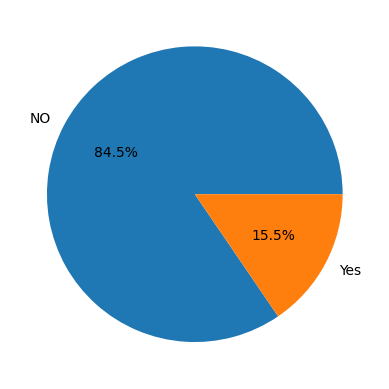

In [5]:
class_cnt= df['Revenue'].value_counts()
plt.pie(class_cnt, labels=['NO','Yes'],autopct='%1.1f%%')
plt.show()

<Axes: >

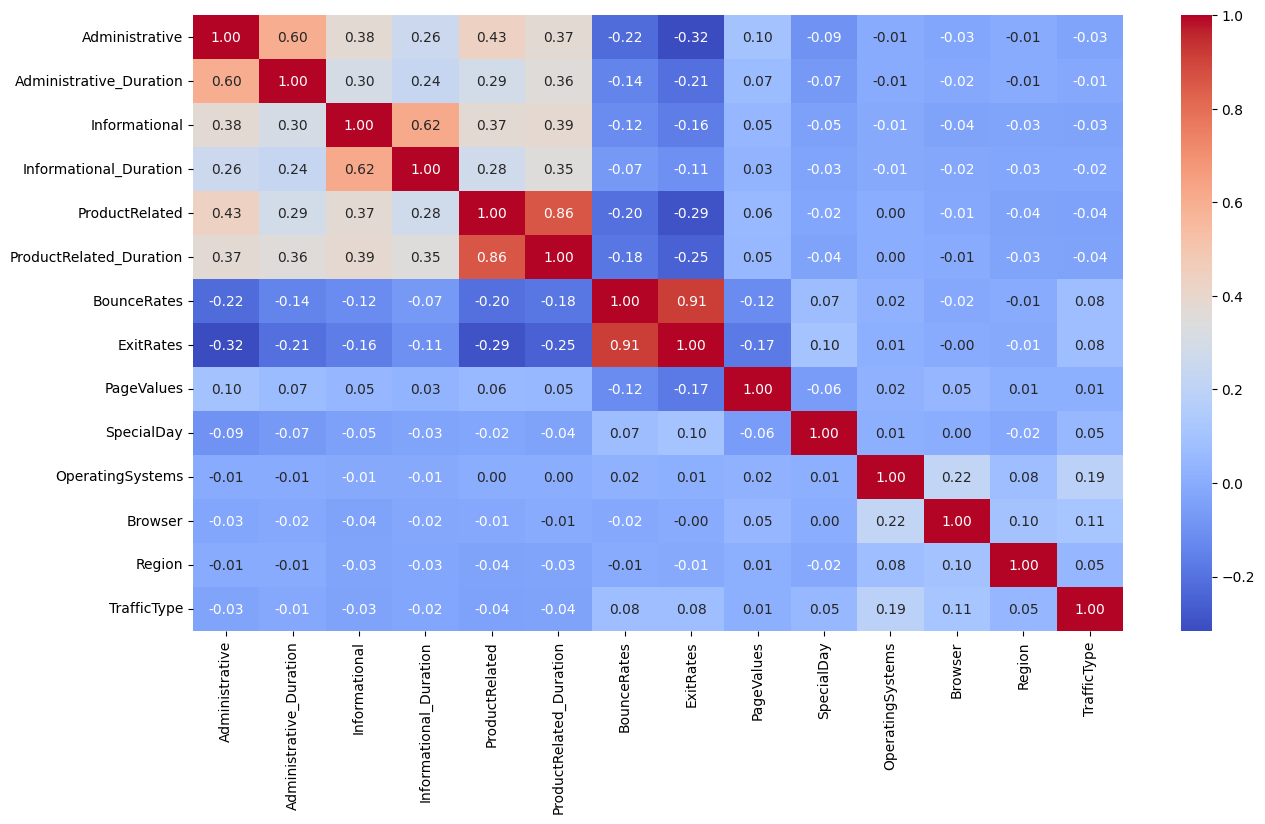

In [6]:
num_col= df.select_dtypes("number")
plt.figure(figsize=(15, 8))
corr_mat= num_col.corr()
sns.heatmap(corr_mat,
           annot= True,
           fmt=".2f",
           cmap="coolwarm")

In [7]:
X= df.drop('Revenue',axis=1)
y= df['Revenue']

In [8]:
le= LabelEncoder()
y= le.fit_transform(y)

In [11]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')  
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier(class_weight='balanced',max_depth=10, ccp_alpha=0.01))
])

In [12]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=15)

In [13]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
y_pred= pipeline.predict(X_test)
print("accuracy score :",accuracy_score(y_test,y_pred))
print("f1 score :",f1_score(y_test,y_pred))

accuracy score : 0.8767234387672344
f1 score : 0.676595744680851


In [16]:
new_data = pd.DataFrame([{
    "Administrative":0,
    "Administrative_Duration":0.0,
    "Informational":0,
    "Informational_Duration":0.0,
    "ProductRelated":2,
    "ProductRelated_Duration":64.0,
    "BounceRates":0.00,
    "ExitRates":0.10,
    "PageValues":0.0,
    "SpecialDay":0.0,
    "Month":"Feb",
    "OperatingSystems":2,
    "Browser":2,
    "Region":1,
    "TrafficType":2,
    "VisitorType":"Returning_Visitor",
    "Weekend":False
}])

pipeline.predict(new_data)

array([0])

In [17]:
import pickle

pickle.dump(pipeline, open("model.pkl", "wb"))